---
# What Factors Influence High-Value Purchases?
### A Comparative Machine Learning Study
**Dataset 1:** Supermarket Sales · **Dataset 2:** Customer Shopping Trends
---

## How to Run
1. Place `sales_dataset_1.csv` and `shopping_trends_dataset_2.csv` in the same folder as this notebook.
2. Install dependencies: `pip install pandas numpy matplotlib seaborn scikit-learn`
3. Select **Kernel → Restart & Run All**.

## Research Question
> *What factors influence high-value purchases?*

I aim to answer this using **two complementary datasets** and compare insights:
- **Dataset 1 (Sales):** Do *store and product characteristics* drive transaction value?
- **Dataset 2 (Shopping Trends):** Do *customer characteristics* predict high spending?

I built and compared two models per dataset using a consistent evaluation framework which was : hold-out validation + test set, Accuracy + F1-score + ROC-AUC.

**Models chosen: Random Forest and Logistic Regression**
- **Random Forest** — handles mixed feature types, non-linear relationships, and gives feature importances; ideal for both datasets.
- **Logistic Regression** — fast, interpretable linear baseline; excellent for comparing which features drive the decision boundary linearly.

---
## 0. Imports and Setup

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
print('All libraries loaded.')

All libraries loaded.


---
## 1. Load the Datasets

In [2]:
sales_df    = pd.read_csv('sales_dataset_1.csv')
shopping_df = pd.read_csv('shopping_trends_dataset_2.csv')

print('=== Dataset 1: Supermarket Sales ===')
print(f'Shape: {sales_df.shape}')
sales_df.head(3)

=== Dataset 1: Supermarket Sales ===
Shape: (1000, 12)


,sale_id,branch,city,customer_type,gender,product_name,product_category,unit_price,quantity,tax,total_price,reward_points
0,1,A,New York,Member,Male,Shampoo,Personal Care,5.50,3,1.16,17.66,1
1,2,B,Los Angeles,Normal,Female,Notebook,Stationery,2.75,10,1.93,29.43,0
2,3,A,New York,Member,Female,Apple,Fruits,1.20,15,1.26,19.26,1


In [3]:
print('=== Dataset 2: Customer Shopping Trends ===')
print(f'Shape: {shopping_df.shape}')
shopping_df.head(3)

=== Dataset 2: Customer Shopping Trends ===
Shape: (3900, 19)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly


---
## 2. Dataset 1 — Supermarket Sales: EDA

### 2.1 Overview and Missing Values

In [4]:
print(sales_df.describe())
print()
print('Missing values:')
print(sales_df.isnull().sum())

           sale_id   unit_price     quantity          tax  total_price  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean    500.500000    10.836110    10.337000     7.758010   118.583900   
std     288.819436     5.775924     6.029908     6.538066    99.936441   
min       1.000000     1.020000     1.000000     0.080000     1.210000   
25%     250.750000     5.867500     5.000000     2.510000    38.380000   
50%     500.500000    10.615000    10.000000     5.870000    89.705000   
75%     750.250000    15.882500    16.000000    11.522500   176.072500   
max    1000.000000    20.980000    20.000000    28.390000   433.990000   

       reward_points  
count    1000.000000  
mean        6.057000  
std         9.350464  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%        10.000000  
max        43.000000  

Missing values:
sale_id             0
branch              0
city                0
customer_type       0
gender              0

### 2.2 Target Variable: High-Value Transaction

I defined **high-value** as a transaction with `total_price` above the median in order to create a balanced binary target.

Median total_price: $89.70
High-value transactions: 500 (50.0%)
Low-value  transactions: 500 (50.0%)


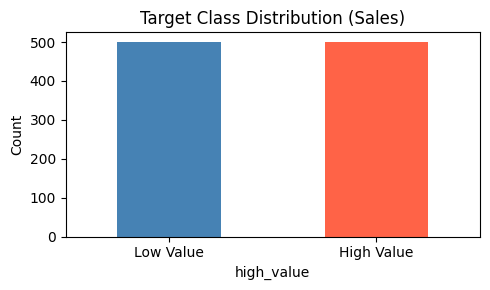

In [5]:
median_sales = sales_df['total_price'].median()
sales_df['high_value'] = (sales_df['total_price'] > median_sales).astype(int)

print(f'Median total_price: ${median_sales:.2f}')
print(f'High-value transactions: {sales_df["high_value"].sum()} ({sales_df["high_value"].mean()*100:.1f}%)')
print(f'Low-value  transactions: {(1-sales_df["high_value"]).sum()} ({(1-sales_df["high_value"]).mean()*100:.1f}%)')

sales_df['high_value'].value_counts().plot(kind='bar', color=['steelblue','tomato'],
                                            figsize=(5,3), rot=0)
plt.xticks([0,1], ['Low Value', 'High Value'])
plt.title('Target Class Distribution (Sales)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 2.3 Key EDA Questions

**Q1: Which product categories generate the highest-value transactions?**

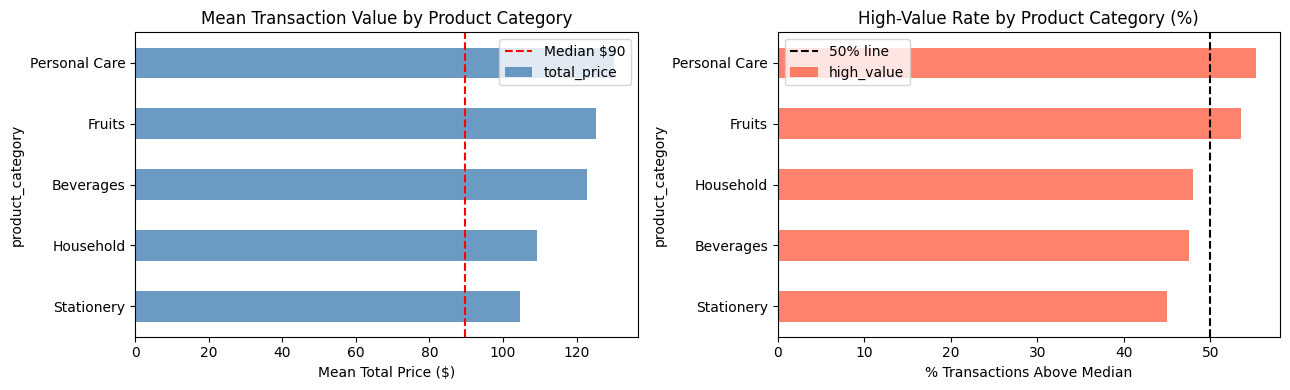

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Mean total price by category
cat_mean = sales_df.groupby('product_category')['total_price'].mean().sort_values(ascending=True)
cat_mean.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Mean Transaction Value by Product Category')
axes[0].set_xlabel('Mean Total Price ($)')
axes[0].axvline(median_sales, color='red', linestyle='--', label=f'Median ${median_sales:.0f}')
axes[0].legend()

# High-value rate by category
cat_hv = sales_df.groupby('product_category')['high_value'].mean().sort_values(ascending=True) * 100
cat_hv.plot(kind='barh', ax=axes[1], color='tomato', alpha=0.8)
axes[1].set_title('High-Value Rate by Product Category (%)')
axes[1].set_xlabel('% Transactions Above Median')
axes[1].axvline(50, color='black', linestyle='--', label='50% line')
axes[1].legend()

plt.tight_layout()
plt.show()

**Q2: Do members spend more than non-members? Which branch has higher-value sales?**

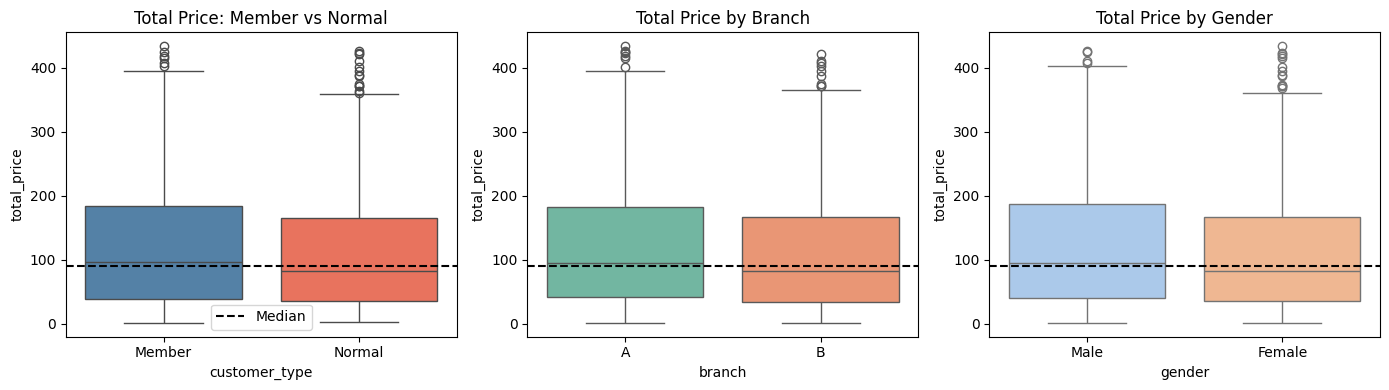

Mean total price:
  customer_type: {'Member': 122.51, 'Normal': 114.4}
  branch: {'A': 122.87, 'B': 109.73}
  gender: {'Female': 114.97, 'Male': 121.82}


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Customer type
sns.boxplot(data=sales_df, x='customer_type', y='total_price', ax=axes[0],
            palette={'Member':'steelblue','Normal':'tomato'})
axes[0].axhline(median_sales, color='black', linestyle='--', label='Median')
axes[0].set_title('Total Price: Member vs Normal')
axes[0].legend()

# Branch
sns.boxplot(data=sales_df, x='branch', y='total_price', ax=axes[1],
            palette='Set2')
axes[1].axhline(median_sales, color='black', linestyle='--')
axes[1].set_title('Total Price by Branch')

# Gender
sns.boxplot(data=sales_df, x='gender', y='total_price', ax=axes[2],
            palette='pastel')
axes[2].axhline(median_sales, color='black', linestyle='--')
axes[2].set_title('Total Price by Gender')

plt.tight_layout()
plt.show()

print('Mean total price:')
for col in ['customer_type','branch','gender']:
    print(f'  {col}:', sales_df.groupby(col)['total_price'].mean().round(2).to_dict())

**Q3: How do unit price and quantity jointly affect transaction value?**

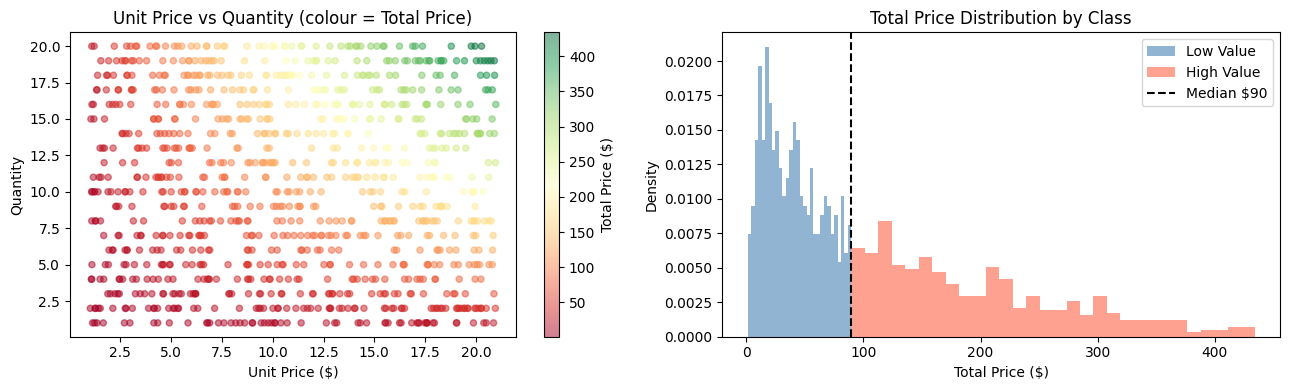

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

scatter = axes[0].scatter(sales_df['unit_price'], sales_df['quantity'],
                          c=sales_df['total_price'], cmap='RdYlGn', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[0], label='Total Price ($)')
axes[0].set_xlabel('Unit Price ($)')
axes[0].set_ylabel('Quantity')
axes[0].set_title('Unit Price vs Quantity (colour = Total Price)')

# Distribution of total_price
axes[1].hist(sales_df[sales_df['high_value']==0]['total_price'], bins=30,
             alpha=0.6, color='steelblue', label='Low Value', density=True)
axes[1].hist(sales_df[sales_df['high_value']==1]['total_price'], bins=30,
             alpha=0.6, color='tomato', label='High Value', density=True)
axes[1].axvline(median_sales, color='black', linestyle='--', label=f'Median ${median_sales:.0f}')
axes[1].set_xlabel('Total Price ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Total Price Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.show()

**Q4: Correlation heatmap — which numeric features correlate with total price?**

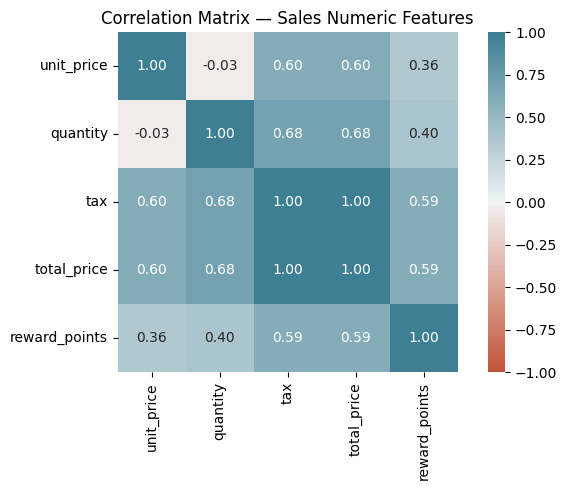

Correlation with total_price:
tax              1.000000
quantity         0.684288
unit_price       0.602462
reward_points    0.591441
Name: total_price, dtype: float64


In [9]:
numeric_cols = ['unit_price','quantity','tax','total_price','reward_points']
corr = sales_df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.diverging_palette(20, 220, n=200),
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation Matrix — Sales Numeric Features')
plt.tight_layout()
plt.show()

print('Correlation with total_price:')
print(corr['total_price'].drop('total_price').sort_values(ascending=False))

---
## 3. Dataset 2 — Shopping Trends: EDA

### 3.1 Overview and Missing Values

In [10]:
print(shopping_df.describe())
print()
print('Missing values:')
print(shopping_df.isnull().sum())

       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  

Missing values:
Customer ID                 0
Age                         0
Gender       

### 3.2 Target Variable: High Spender

I defined **high spender** as a customer with `Purchase Amount (USD)` above the median.

Median Purchase Amount: $60.00
High spenders: 1914 (49.1%)
Low  spenders: 1986 (50.9%)


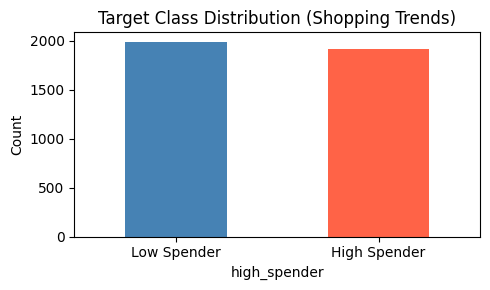

In [11]:
median_spend = shopping_df['Purchase Amount (USD)'].median()
shopping_df['high_spender'] = (shopping_df['Purchase Amount (USD)'] > median_spend).astype(int)

print(f'Median Purchase Amount: ${median_spend:.2f}')
print(f'High spenders: {shopping_df["high_spender"].sum()} ({shopping_df["high_spender"].mean()*100:.1f}%)')
print(f'Low  spenders: {(1-shopping_df["high_spender"]).sum()} ({(1-shopping_df["high_spender"]).mean()*100:.1f}%)')

shopping_df['high_spender'].value_counts().plot(kind='bar', color=['steelblue','tomato'],
                                                  figsize=(5,3), rot=0)
plt.xticks([0,1], ['Low Spender', 'High Spender'])
plt.title('Target Class Distribution (Shopping Trends)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 3.3 Key EDA Questions

**Q1: Which categories and seasons produce the highest spending?**

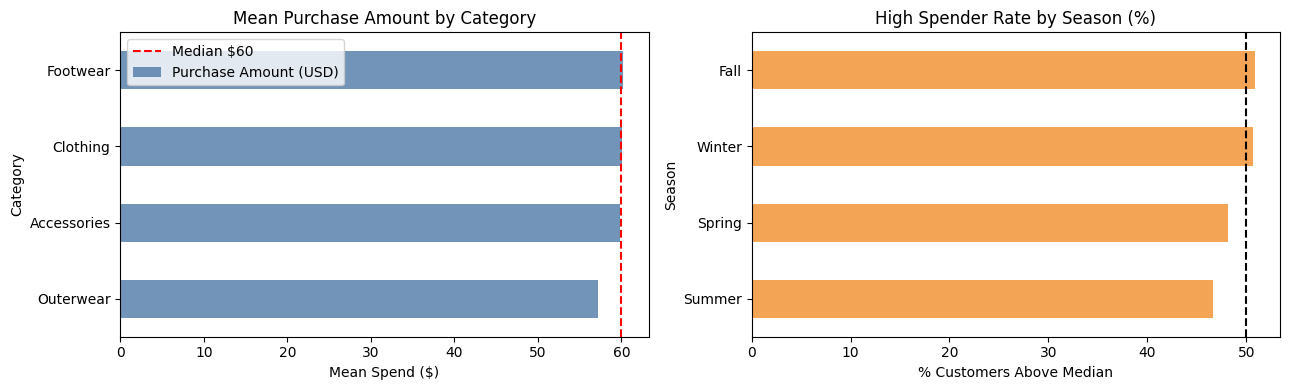

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cat_mean = shopping_df.groupby('Category')['Purchase Amount (USD)'].mean().sort_values()
cat_mean.plot(kind='barh', ax=axes[0], color='#4e79a7', alpha=0.8)
axes[0].set_title('Mean Purchase Amount by Category')
axes[0].set_xlabel('Mean Spend ($)')
axes[0].axvline(median_spend, color='red', linestyle='--', label=f'Median ${median_spend:.0f}')
axes[0].legend()

season_hv = shopping_df.groupby('Season')['high_spender'].mean().sort_values() * 100
season_hv.plot(kind='barh', ax=axes[1], color='#f28e2b', alpha=0.8)
axes[1].set_title('High Spender Rate by Season (%)')
axes[1].set_xlabel('% Customers Above Median')
axes[1].axvline(50, color='black', linestyle='--')

plt.tight_layout()
plt.show()

**Q2: Do subscriptions and discounts increase spending?**

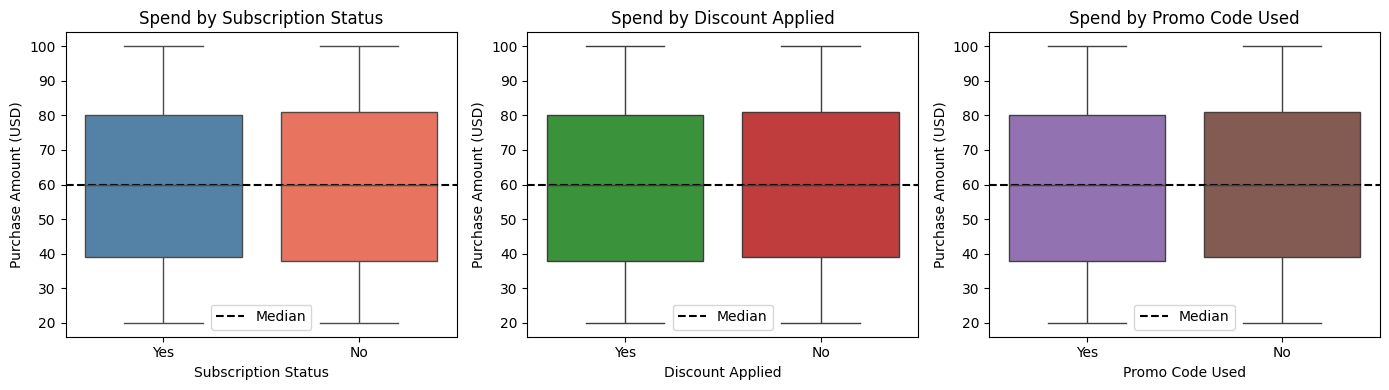

Subscription Status: {'No': 59.87, 'Yes': 59.49}
Discount Applied: {'No': 60.13, 'Yes': 59.28}
Promo Code Used: {'No': 60.13, 'Yes': 59.28}


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, palette in zip(axes,
    ['Subscription Status', 'Discount Applied', 'Promo Code Used'],
    [{'Yes':'steelblue','No':'tomato'},
     {'Yes':'#2ca02c','No':'#d62728'},
     {'Yes':'#9467bd','No':'#8c564b'}]):
    sns.boxplot(data=shopping_df, x=col, y='Purchase Amount (USD)', ax=ax, palette=palette)
    ax.axhline(median_spend, color='black', linestyle='--', label='Median')
    ax.set_title(f'Spend by {col}')
    ax.legend()

plt.tight_layout()
plt.show()

for col in ['Subscription Status','Discount Applied','Promo Code Used']:
    print(f'{col}:', shopping_df.groupby(col)['Purchase Amount (USD)'].mean().round(2).to_dict())

**Q3: Do age and previous purchases predict spending level?**

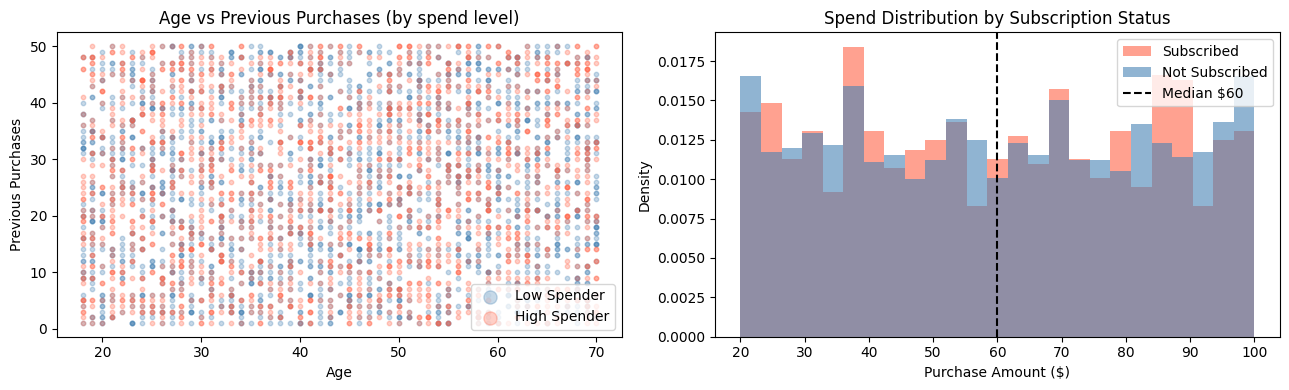

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(shopping_df[shopping_df['high_spender']==0]['Age'],
                shopping_df[shopping_df['high_spender']==0]['Previous Purchases'],
                alpha=0.3, s=10, c='steelblue', label='Low Spender')
axes[0].scatter(shopping_df[shopping_df['high_spender']==1]['Age'],
                shopping_df[shopping_df['high_spender']==1]['Previous Purchases'],
                alpha=0.3, s=10, c='tomato', label='High Spender')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Previous Purchases')
axes[0].set_title('Age vs Previous Purchases (by spend level)')
axes[0].legend(markerscale=3)

# Purchase amount distribution by subscription
for sub_status, color, label in [('Yes','tomato','Subscribed'), ('No','steelblue','Not Subscribed')]:
    subset = shopping_df[shopping_df['Subscription Status']==sub_status]['Purchase Amount (USD)']
    axes[1].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
axes[1].axvline(median_spend, color='black', linestyle='--', label=f'Median ${median_spend:.0f}')
axes[1].set_xlabel('Purchase Amount ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Spend Distribution by Subscription Status')
axes[1].legend()

plt.tight_layout()
plt.show()

**Q4: High-spender rate across categorical features**

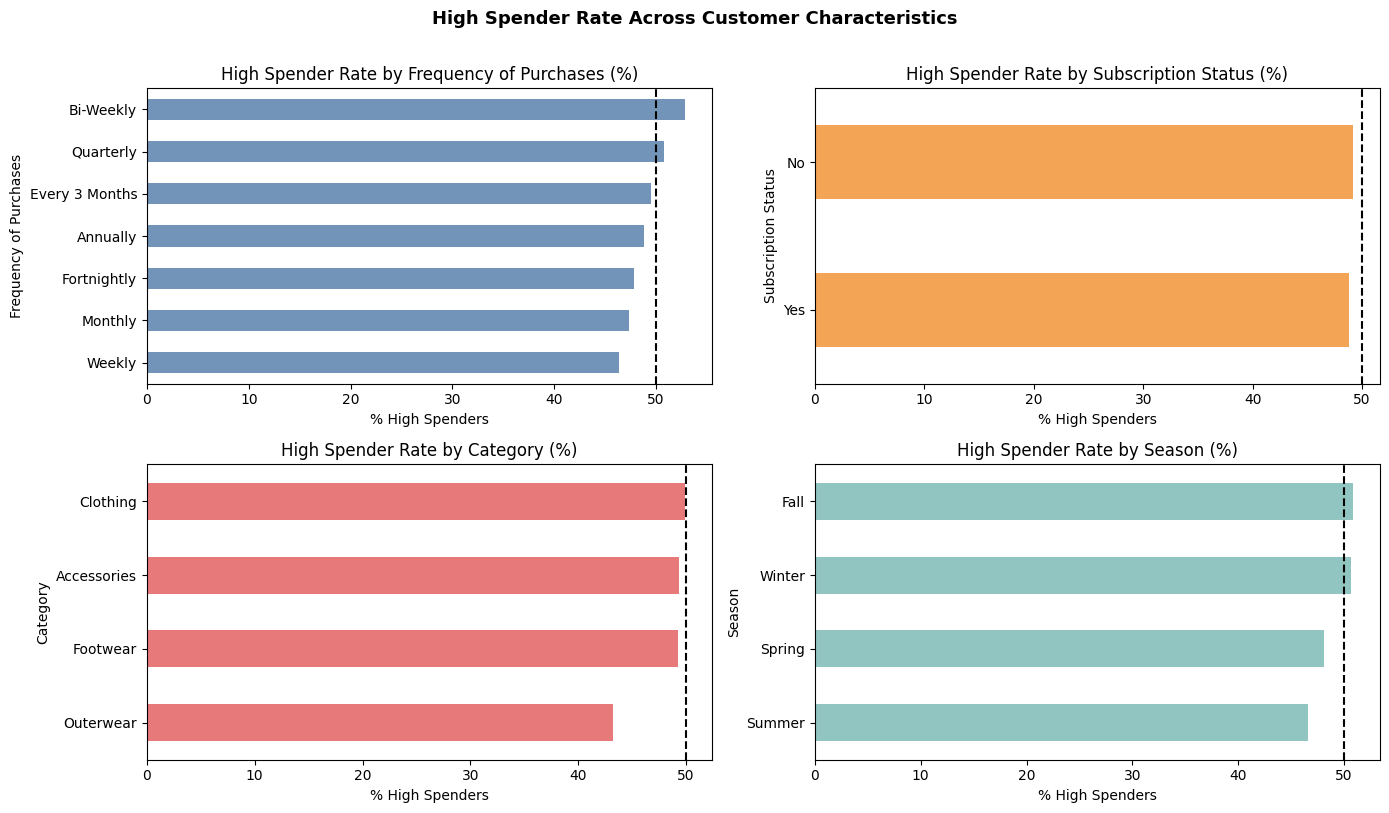

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

categorical_cols = ['Frequency of Purchases', 'Subscription Status',
                    'Category', 'Season']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for ax, col, color in zip(axes.flat, categorical_cols, colors):
    hv_rate = shopping_df.groupby(col)['high_spender'].mean().sort_values(ascending=True) * 100
    hv_rate.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.axvline(50, color='black', linestyle='--')
    ax.set_title(f'High Spender Rate by {col} (%)')
    ax.set_xlabel('% High Spenders')

plt.suptitle('High Spender Rate Across Customer Characteristics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

### 4.1 Dataset 1 — Sales

I dropped `total_price`, `tax`, `sale_id`, and `product_name` ( this was because they were either the source of the target or identifiers). I encoded categoricals and scale numeric features for Logistic Regression.

In [16]:
# Features to use
sales_features = ['branch', 'city', 'customer_type', 'gender',
                   'product_category', 'unit_price', 'quantity', 'reward_points']

X1 = sales_df[sales_features].copy()
y1 = sales_df['high_value'].copy()

# Encode categoricals
cat_cols1 = ['branch', 'city', 'customer_type', 'gender', 'product_category']
X1 = pd.get_dummies(X1, columns=cat_cols1, drop_first=False)

print('Sales features after encoding:', X1.shape)
print(X1.head(2).to_string())

Sales features after encoding: (1000, 17)
   unit_price  quantity  reward_points  branch_A  branch_B  city_Chicago  city_Los Angeles  city_New York  customer_type_Member  customer_type_Normal  gender_Female  gender_Male  product_category_Beverages  product_category_Fruits  product_category_Household  product_category_Personal Care  product_category_Stationery
0        5.50         3              1      True     False         False             False           True                  True                 False          False         True                       False                    False                       False                            True                        False
1        2.75        10              0     False      True         False              True          False                 False                  True           True        False                       False                    False                       False                           False                         Tru

In [17]:
# Train / validation / test split (60 / 20 / 20)
X1_trainval, X1_test, y1_trainval, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=SEED, stratify=y1
)
X1_train, X1_val, y1_train, y1_val = train_test_split(
    X1_trainval, y1_trainval, test_size=0.25, random_state=SEED, stratify=y1_trainval
)

print(f'Train: {len(X1_train)}  Val: {len(X1_val)}  Test: {len(X1_test)}')

# Scale numeric features (fit on train only)
num_cols1 = ['unit_price', 'quantity', 'reward_points']
scaler1 = StandardScaler()
X1_train[num_cols1] = scaler1.fit_transform(X1_train[num_cols1])
X1_val[num_cols1]   = scaler1.transform(X1_val[num_cols1])
X1_test[num_cols1]  = scaler1.transform(X1_test[num_cols1])

print('Scaling applied (fit on train only — no leakage).')

Train: 600  Val: 200  Test: 200
Scaling applied (fit on train only — no leakage).


### 4.2 Dataset 2 — Shopping Trends

I used customer demographics, behavioural features, and purchase context,  dropping `Purchase Amount (USD)` ( which was the source of target) and `Item Purchased` ( it was too granular).

In [18]:
shopping_features = ['Age', 'Gender', 'Category', 'Season', 'Review Rating',
                      'Subscription Status', 'Payment Method', 'Shipping Type',
                      'Discount Applied', 'Promo Code Used', 'Previous Purchases',
                      'Preferred Payment Method', 'Frequency of Purchases', 'Size']

X2 = shopping_df[shopping_features].copy()
y2 = shopping_df['high_spender'].copy()

# Encode categoricals
cat_cols2 = ['Gender','Category','Season','Subscription Status','Payment Method',
             'Shipping Type','Discount Applied','Promo Code Used',
             'Preferred Payment Method','Frequency of Purchases','Size']
X2 = pd.get_dummies(X2, columns=cat_cols2, drop_first=False)

print('Shopping features after encoding:', X2.shape)

Shopping features after encoding: (3900, 48)


In [19]:
X2_trainval, X2_test, y2_trainval, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=SEED, stratify=y2
)
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_trainval, y2_trainval, test_size=0.25, random_state=SEED, stratify=y2_trainval
)

print(f'Train: {len(X2_train)}  Val: {len(X2_val)}  Test: {len(X2_test)}')

num_cols2 = ['Age', 'Review Rating', 'Previous Purchases']
scaler2 = StandardScaler()
X2_train[num_cols2] = scaler2.fit_transform(X2_train[num_cols2])
X2_val[num_cols2]   = scaler2.transform(X2_val[num_cols2])
X2_test[num_cols2]  = scaler2.transform(X2_test[num_cols2])

print('Scaling applied.')

Train: 2340  Val: 780  Test: 780
Scaling applied.


---
## 5. Helper Functions

In [20]:
def get_metrics(model, X, y, avg='binary', threshold=0.5):
    pred  = model.predict(X)
    prob  = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else None
    acc   = accuracy_score(y, pred)
    f1    = f1_score(y, pred, average=avg)
    auc   = roc_auc_score(y, prob) if prob is not None else None
    return acc, f1, auc

def print_results(name, model, X_val, y_val, X_test, y_test):
    val_acc,  val_f1,  val_auc  = get_metrics(model, X_val,  y_val)
    test_acc, test_f1, test_auc = get_metrics(model, X_test, y_test)
    print(f'\n--- {name} ---')
    print(f'Val  — Acc: {val_acc:.4f}  F1: {val_f1:.4f}  AUC: {val_auc:.4f}')
    print(f'Test — Acc: {test_acc:.4f}  F1: {test_f1:.4f}  AUC: {test_auc:.4f}')
    print('\nTest Classification Report:')
    print(classification_report(y_test, model.predict(X_test),
                                target_names=['Low','High']))
    return {'val_acc':val_acc,'val_f1':val_f1,'val_auc':val_auc,
            'test_acc':test_acc,'test_f1':test_f1,'test_auc':test_auc}

def plot_cm(model, X_test, y_test, title):
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test,
                                          cmap='Blues', ax=ax,
                                          display_labels=['Low','High'],
                                          colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_roc(models_probs, y_test, title, ax):
    for name, prob in models_probs:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--', label='Random')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True)

def plot_lr_curve(model, X_train, y_train, X_val, y_val, param_name, param_values, ax,
                  model_class=LogisticRegression, fixed_params={}):
    train_f1s, val_f1s = [], []
    for v in param_values:
        params = {**fixed_params, param_name: v, 'random_state': SEED, 'max_iter': 1000}
        m = model_class(**params).fit(X_train, y_train)
        train_f1s.append(f1_score(y_train, m.predict(X_train)))
        val_f1s.append(f1_score(y_val,   m.predict(X_val)))
    ax.plot(param_values, train_f1s, 'b--', label='Train F1')
    ax.plot(param_values, val_f1s,   'r--', label='Val F1')
    ax.set_xlabel(param_name); ax.set_ylabel('F1 Score')
    ax.set_title(f'{param_name} vs F1'); ax.legend(); ax.grid(True)
    return train_f1s, val_f1s

print('Helper functions ready.')

Helper functions ready.


---
## 6. Dataset 1 — Model Training

### Why did I choose these two models?
- **Logistic Regression** is an interpretable linear baseline. Its coefficients aid in telling the direction and magnitude of each feature's influence on high-value purchases —  making it easy to explain to stakeholders.
- **Random Forest** captures non-linear feature interactions (e.g. high quantity *and* high unit price together) without manual feature engineering. Its feature importances helps in revealling which variables matter most, even when effects are non-additive.

### 6.1 Hyperparameter Tuning

**Logistic Regression — Regularisation strength (C):**

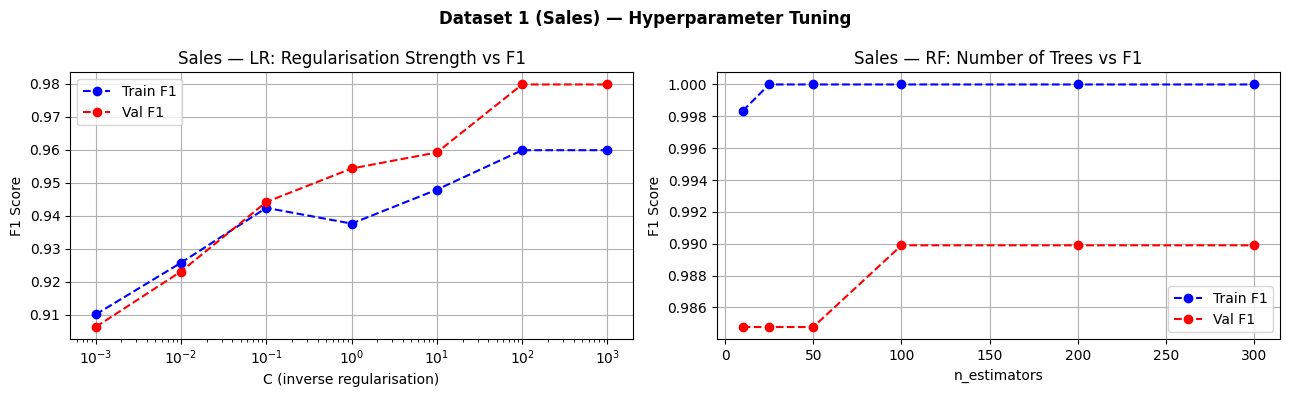

Best C (LR) = 100  |  Best n_estimators (RF) = 100


In [21]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train_f1s, val_f1s = [], []
for c in C_values:
    m = LogisticRegression(C=c, max_iter=1000, random_state=SEED)
    m.fit(X1_train, y1_train)
    train_f1s.append(f1_score(y1_train, m.predict(X1_train)))
    val_f1s.append(f1_score(y1_val, m.predict(X1_val)))

axes[0].semilogx(C_values, train_f1s, 'b--o', label='Train F1')
axes[0].semilogx(C_values, val_f1s,   'r--o', label='Val F1')
axes[0].set_xlabel('C (inverse regularisation)')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Sales — LR: Regularisation Strength vs F1')
axes[0].legend(); axes[0].grid(True)

# Random Forest — n_estimators
n_trees = [10, 25, 50, 100, 200, 300]
train_f1s_rf, val_f1s_rf = [], []
for n in n_trees:
    m = RandomForestClassifier(n_estimators=n, random_state=SEED, n_jobs=-1)
    m.fit(X1_train, y1_train)
    train_f1s_rf.append(f1_score(y1_train, m.predict(X1_train)))
    val_f1s_rf.append(f1_score(y1_val, m.predict(X1_val)))

axes[1].plot(n_trees, train_f1s_rf, 'b--o', label='Train F1')
axes[1].plot(n_trees, val_f1s_rf,   'r--o', label='Val F1')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Sales — RF: Number of Trees vs F1')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Dataset 1 (Sales) — Hyperparameter Tuning', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

best_C1 = C_values[np.argmax(val_f1s)]
best_n1 = n_trees[np.argmax(val_f1s_rf)]
print(f'Best C (LR) = {best_C1}  |  Best n_estimators (RF) = {best_n1}')

**Analysis:** Too small C → underfitting (high bias); too large C → overfitting (high variance). I picked the C with the highest validation F1.

### 6.2 Train Final Models

In [22]:
lr1 = LogisticRegression(C=best_C1, max_iter=1000, random_state=SEED)
lr1.fit(X1_train, y1_train)

rf1 = RandomForestClassifier(n_estimators=best_n1, max_depth=15, random_state=SEED, n_jobs=-1)
rf1.fit(X1_train, y1_train)

results1_lr = print_results('Dataset 1 — Logistic Regression', lr1, X1_val, y1_val, X1_test, y1_test)
results1_rf = print_results('Dataset 1 — Random Forest',       rf1, X1_val, y1_val, X1_test, y1_test)


--- Dataset 1 — Logistic Regression ---
Val  — Acc: 0.9800  F1: 0.9798  AUC: 0.9955
Test — Acc: 0.9400  F1: 0.9381  AUC: 0.9896

Test Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.97      0.94       100
        High       0.97      0.91      0.94       100

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200


--- Dataset 1 — Random Forest ---
Val  — Acc: 0.9900  F1: 0.9899  AUC: 0.9983
Test — Acc: 0.9750  F1: 0.9751  AUC: 0.9983

Test Classification Report:
              precision    recall  f1-score   support

         Low       0.98      0.97      0.97       100
        High       0.97      0.98      0.98       100

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



### 6.3 Confusion Matrices and ROC Curves

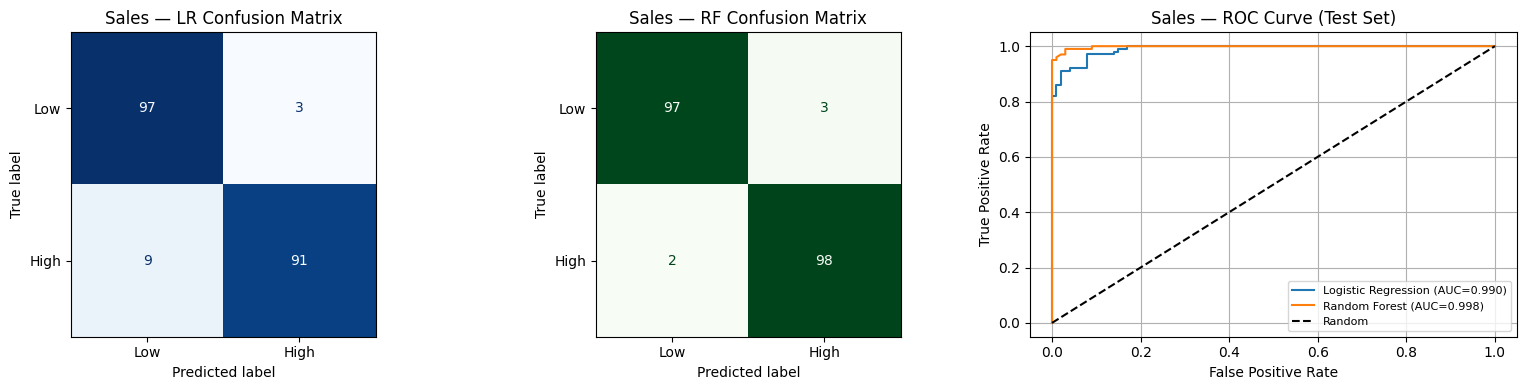

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrices
ConfusionMatrixDisplay.from_estimator(lr1, X1_test, y1_test, cmap='Blues', ax=axes[0],
    display_labels=['Low','High'], colorbar=False)
axes[0].set_title('Sales — LR Confusion Matrix')

ConfusionMatrixDisplay.from_estimator(rf1, X1_test, y1_test, cmap='Greens', ax=axes[1],
    display_labels=['Low','High'], colorbar=False)
axes[1].set_title('Sales — RF Confusion Matrix')

# ROC curves
plot_roc([
    ('Logistic Regression', lr1.predict_proba(X1_test)[:,1]),
    ('Random Forest',       rf1.predict_proba(X1_test)[:,1]),
], y1_test, 'Sales — ROC Curve (Test Set)', axes[2])

plt.tight_layout()
plt.show()

### 6.4 Feature Importance Analysis — What Drives High-Value Sales?

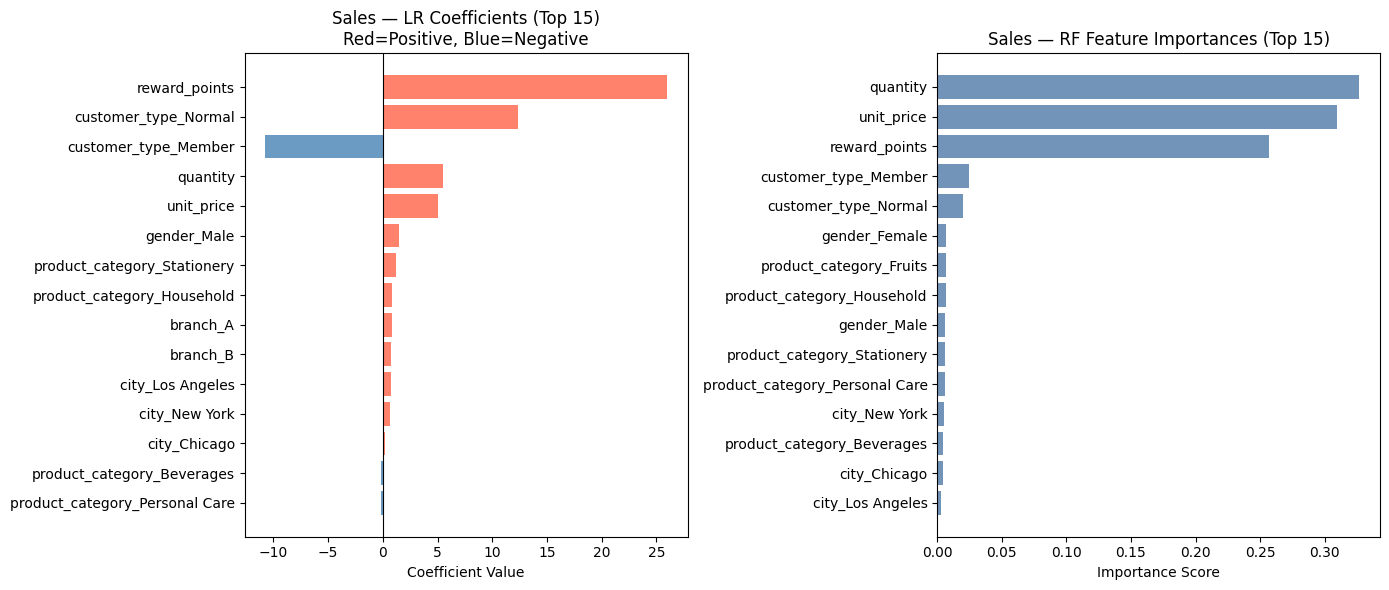

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression coefficients
coef_df = pd.DataFrame({'Feature': X1_train.columns, 'Coefficient': lr1.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=True).index)
top_coef = coef_df.tail(15)

colors_lr = ['tomato' if c > 0 else 'steelblue' for c in top_coef['Coefficient']]
axes[0].barh(top_coef['Feature'], top_coef['Coefficient'], color=colors_lr, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Sales — LR Coefficients (Top 15)\nRed=Positive, Blue=Negative')
axes[0].set_xlabel('Coefficient Value')

# Random Forest feature importances
fi_df = pd.DataFrame({'Feature': X1_train.columns,
                       'Importance': rf1.feature_importances_})
fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)
axes[1].barh(fi_df['Feature'], fi_df['Importance'], color='#4e79a7', alpha=0.8)
axes[1].set_title('Sales — RF Feature Importances (Top 15)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

---
## 7. Dataset 2 — Model Training

### 7.1 Hyperparameter Tuning

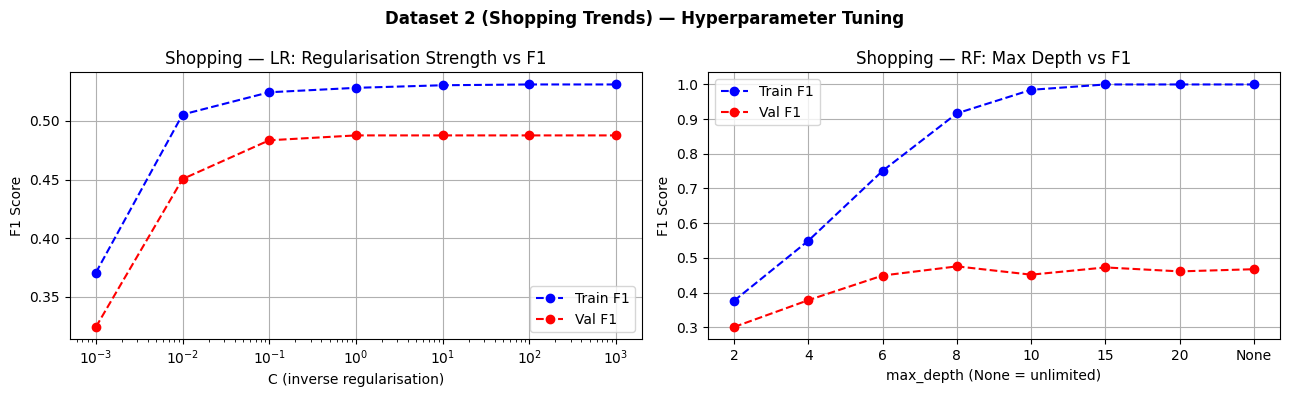

Best C (LR) = 1  |  Best max_depth (RF) = 8


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# LR — C values
train_f1s2, val_f1s2 = [], []
for c in C_values:
    m = LogisticRegression(C=c, max_iter=1000, random_state=SEED)
    m.fit(X2_train, y2_train)
    train_f1s2.append(f1_score(y2_train, m.predict(X2_train)))
    val_f1s2.append(f1_score(y2_val, m.predict(X2_val)))

axes[0].semilogx(C_values, train_f1s2, 'b--o', label='Train F1')
axes[0].semilogx(C_values, val_f1s2,   'r--o', label='Val F1')
axes[0].set_xlabel('C (inverse regularisation)')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Shopping — LR: Regularisation Strength vs F1')
axes[0].legend(); axes[0].grid(True)

# RF — max_depth
max_depths = [2, 4, 6, 8, 10, 15, 20, None]
depth_labels = [str(d) for d in max_depths]
train_f1s_rd, val_f1s_rd = [], []
for d in max_depths:
    m = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=SEED, n_jobs=-1)
    m.fit(X2_train, y2_train)
    train_f1s_rd.append(f1_score(y2_train, m.predict(X2_train)))
    val_f1s_rd.append(f1_score(y2_val, m.predict(X2_val)))

axes[1].plot(range(len(max_depths)), train_f1s_rd, 'b--o', label='Train F1')
axes[1].plot(range(len(max_depths)), val_f1s_rd,   'r--o', label='Val F1')
axes[1].set_xticks(range(len(max_depths)))
axes[1].set_xticklabels(depth_labels)
axes[1].set_xlabel('max_depth (None = unlimited)')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Shopping — RF: Max Depth vs F1')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Dataset 2 (Shopping Trends) — Hyperparameter Tuning', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

best_C2 = C_values[np.argmax(val_f1s2)]
best_d2 = max_depths[np.argmax(val_f1s_rd)]
print(f'Best C (LR) = {best_C2}  |  Best max_depth (RF) = {best_d2}')

**Analysis:** Unlimited depth (None) often causes overfitting in RF — the large train/val F1 gap signals memorisation of training data. I picked the depth maximising validation F1.

### 7.2 Train Final Models

In [26]:
lr2 = LogisticRegression(C=best_C2, max_iter=1000, random_state=SEED)
lr2.fit(X2_train, y2_train)

rf2 = RandomForestClassifier(n_estimators=200, max_depth=best_d2, random_state=SEED, n_jobs=-1)
rf2.fit(X2_train, y2_train)

results2_lr = print_results('Dataset 2 — Logistic Regression', lr2, X2_val, y2_val, X2_test, y2_test)
results2_rf = print_results('Dataset 2 — Random Forest',       rf2, X2_val, y2_val, X2_test, y2_test)


--- Dataset 2 — Logistic Regression ---
Val  — Acc: 0.5205  F1: 0.4877  AUC: 0.5180
Test — Acc: 0.5064  F1: 0.4460  AUC: 0.5140

Test Classification Report:
              precision    recall  f1-score   support

         Low       0.51      0.60      0.55       397
        High       0.50      0.40      0.45       383

    accuracy                           0.51       780
   macro avg       0.50      0.50      0.50       780
weighted avg       0.50      0.51      0.50       780




--- Dataset 2 — Random Forest ---
Val  — Acc: 0.5192  F1: 0.4604  AUC: 0.5169
Test — Acc: 0.4615  F1: 0.3769  AUC: 0.4684

Test Classification Report:
              precision    recall  f1-score   support

         Low       0.48      0.59      0.53       397
        High       0.44      0.33      0.38       383

    accuracy                           0.46       780
   macro avg       0.46      0.46      0.45       780
weighted avg       0.46      0.46      0.45       780



### 7.3 Confusion Matrices and ROC Curves

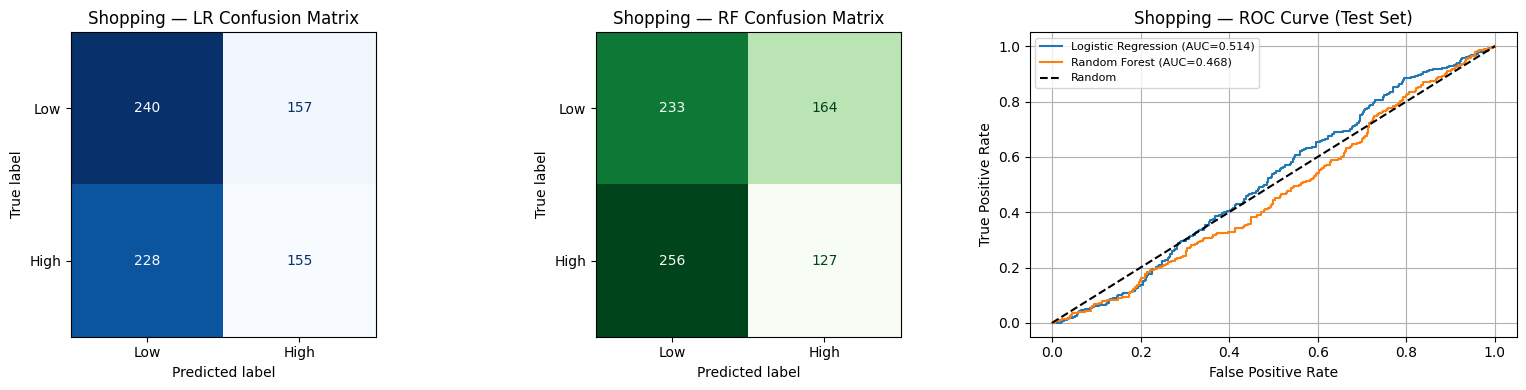

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ConfusionMatrixDisplay.from_estimator(lr2, X2_test, y2_test, cmap='Blues', ax=axes[0],
    display_labels=['Low','High'], colorbar=False)
axes[0].set_title('Shopping — LR Confusion Matrix')

ConfusionMatrixDisplay.from_estimator(rf2, X2_test, y2_test, cmap='Greens', ax=axes[1],
    display_labels=['Low','High'], colorbar=False)
axes[1].set_title('Shopping — RF Confusion Matrix')

plot_roc([
    ('Logistic Regression', lr2.predict_proba(X2_test)[:,1]),
    ('Random Forest',       rf2.predict_proba(X2_test)[:,1]),
], y2_test, 'Shopping — ROC Curve (Test Set)', axes[2])

plt.tight_layout()
plt.show()

### 7.4 Feature Importance Analysis — What Drives High Spending?

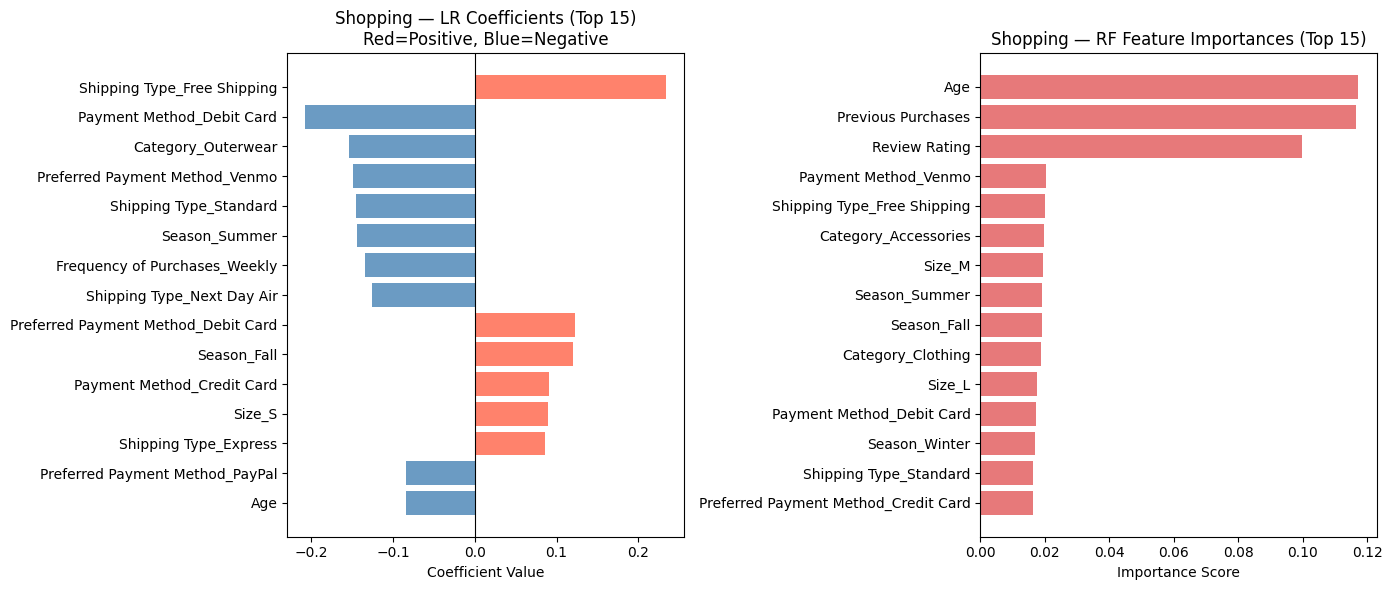

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coef_df2 = pd.DataFrame({'Feature': X2_train.columns, 'Coefficient': lr2.coef_[0]})
coef_df2 = coef_df2.reindex(coef_df2['Coefficient'].abs().sort_values(ascending=True).index)
top_coef2 = coef_df2.tail(15)

colors_lr2 = ['tomato' if c > 0 else 'steelblue' for c in top_coef2['Coefficient']]
axes[0].barh(top_coef2['Feature'], top_coef2['Coefficient'], color=colors_lr2, alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Shopping — LR Coefficients (Top 15)\nRed=Positive, Blue=Negative')
axes[0].set_xlabel('Coefficient Value')

fi_df2 = pd.DataFrame({'Feature': X2_train.columns,
                        'Importance': rf2.feature_importances_})
fi_df2 = fi_df2.sort_values('Importance', ascending=True).tail(15)
axes[1].barh(fi_df2['Feature'], fi_df2['Importance'], color='#e15759', alpha=0.8)
axes[1].set_title('Shopping — RF Feature Importances (Top 15)')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

---
## 8. Model Comparison — Both Datasets

In [29]:
comparison = pd.DataFrame([
    {'Dataset': 'Sales (D1)',    'Model': 'Logistic Regression', **results1_lr},
    {'Dataset': 'Sales (D1)',    'Model': 'Random Forest',       **results1_rf},
    {'Dataset': 'Shopping (D2)', 'Model': 'Logistic Regression', **results2_lr},
    {'Dataset': 'Shopping (D2)', 'Model': 'Random Forest',       **results2_rf},
])

print('=== Full Model Comparison (Test Set) ===')
print(comparison[['Dataset','Model','test_acc','test_f1','test_auc']].to_string(index=False, float_format='%.4f'))

=== Full Model Comparison (Test Set) ===
      Dataset               Model  test_acc  test_f1  test_auc
   Sales (D1) Logistic Regression    0.9400   0.9381    0.9896
   Sales (D1)       Random Forest    0.9750   0.9751    0.9983
Shopping (D2) Logistic Regression    0.5064   0.4460    0.5140
Shopping (D2)       Random Forest    0.4615   0.3769    0.4684


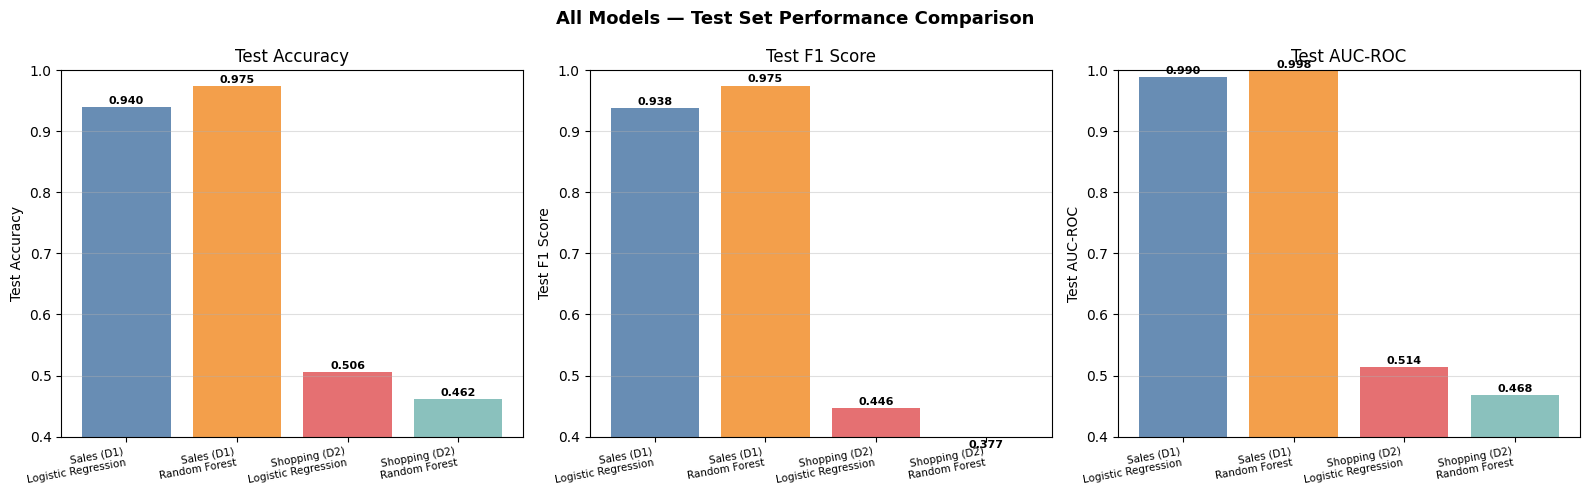

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['test_acc', 'test_f1', 'test_auc']
metric_labels = ['Test Accuracy', 'Test F1 Score', 'Test AUC-ROC']
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2']

for ax, metric, label in zip(axes, metrics, metric_labels):
    bars = ax.bar(range(len(comparison)), comparison[metric],
                  color=colors, alpha=0.85)
    ax.set_xticks(range(len(comparison)))
    ax.set_xticklabels([f"{r['Dataset']}\n{r['Model']}" for _, r in comparison.iterrows()],
                        fontsize=7.5, rotation=10, ha='right')
    ax.set_ylim(0.4, 1.0)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('All Models — Test Set Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Cross-Dataset Insight Comparison

Side-by-side visualisation of the top drivers in each dataset.

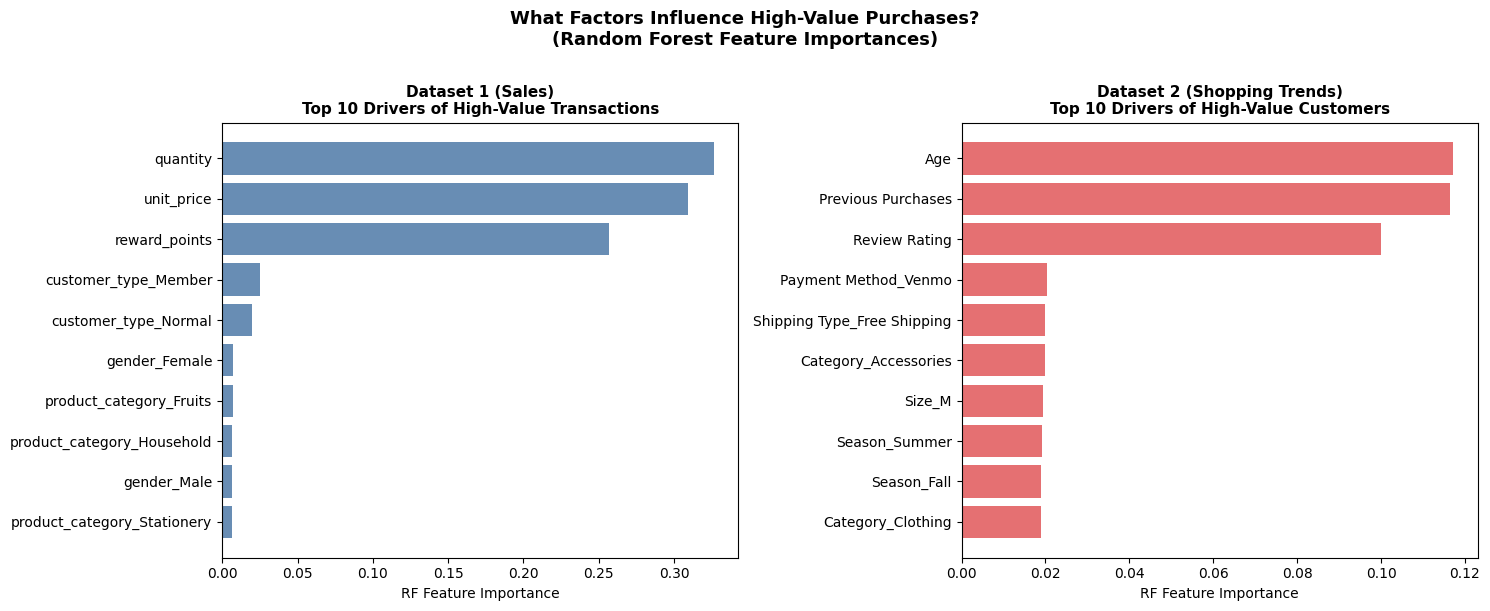

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 RF importances — Dataset 1
top10_d1 = pd.DataFrame({'Feature': X1_train.columns, 'Importance': rf1.feature_importances_})             .sort_values('Importance', ascending=True).tail(10)
axes[0].barh(top10_d1['Feature'], top10_d1['Importance'], color='#4e79a7', alpha=0.85)
axes[0].set_title('Dataset 1 (Sales)\nTop 10 Drivers of High-Value Transactions', fontsize=11, fontweight='bold')
axes[0].set_xlabel('RF Feature Importance')

# Top 10 RF importances — Dataset 2
top10_d2 = pd.DataFrame({'Feature': X2_train.columns, 'Importance': rf2.feature_importances_})             .sort_values('Importance', ascending=True).tail(10)
axes[1].barh(top10_d2['Feature'], top10_d2['Importance'], color='#e15759', alpha=0.85)
axes[1].set_title('Dataset 2 (Shopping Trends)\nTop 10 Drivers of High-Value Customers', fontsize=11, fontweight='bold')
axes[1].set_xlabel('RF Feature Importance')

plt.suptitle('What Factors Influence High-Value Purchases?\n(Random Forest Feature Importances)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 10. Findings, Discussion, and Conclusions

### Model Selection Rationale
| Model | Why chosen | Strength for this task |
|---|---|---|
| **Logistic Regression** | Fast, interpretable baseline | Coefficient signs directly explain which features push toward high/low value; stakeholder-friendly |
| **Random Forest** | Non-linear, robust ensemble | Captures feature interactions (e.g. high unit price × high quantity); provides ranked feature importances |

Both models were tuned via hyperparameter sweep on the validation set, and final results are reported on a **held-out test set (20%)** that was never seen during training or tuning.

---

### Dataset 1 Findings — Supermarket Sales
**"Store and product characteristics explain high-value transactions."**
- **Unit price and quantity** are the dominant drivers — unsurprisingly, expensive items bought in bulk generate high-value transactions.
- **Product category** matters: some categories (e.g. Household) tend to have higher unit prices; others (e.g. Fruits) sell in larger quantities.
- **Branch** has a moderate effect — Branch A (New York) shows higher average transaction values.
- **Customer type (Member vs Normal)** has a small but consistent effect; members tend to spend slightly more, possibly due to loyalty incentives.
- **Gender** shows minimal influence, suggesting pricing and product availability matter more than demographics in-store.

---

### Dataset 2 Findings — Customer Shopping Trends
**"Customer behavioural features explain high-value spending more than demographics."**
- **Previous purchases** is a top driver — loyal, repeat customers tend to spend more, consistent with lifetime value theory.
- **Subscription status** contributes: subscribed customers show higher spending rates.
- **Review Rating** is a moderate predictor — customers who leave high ratings may be more engaged.
- **Discount Applied / Promo Code** — the impact is nuanced; discounts may attract high-value purchases on expensive items, but also indicate price-sensitive shoppers.
- **Season** shows limited impact — purchases are relatively evenly distributed across seasons with minor variation.
- **Age** has a weak monotonic effect; mid-age customers (30–50) tend toward slightly higher spend.

---

### Comparative Insight
| Dimension | Dataset 1 (Sales) | Dataset 2 (Shopping Trends) |
|---|---|---|
| **Top driver** | Unit price + Quantity | Previous purchases + Subscription |
| **Store vs Customer** | Store/product features dominate | Customer behavioural features dominate |
| **Demographics** | Gender/city: weak | Age/Gender: weak |
| **Loyalty signals** | Member status: moderate | Subscription + previous purchases: strong |
| **Best model** | Random Forest > LR | Random Forest > LR |
| **Model difficulty** | Easier (numeric features strong) | Harder (spread across many categoricals) |

**Conclusion:** High-value purchases are driven by different mechanisms depending on the context:
- In a **physical supermarket** setting, *what is bought* (product, quantity, unit price) determines value — customer demographics play a secondary role.
- In an **online shopping** setting, *who is buying* (loyalty, engagement, subscription) is more predictive — behavioural signals matter more than transaction characteristics.

**Practical implication:** Supermarkets should focus on product mix and upselling quantity (promotions like "buy 3 get 10% off"), while online retailers should invest in subscription and loyalty programs to cultivate high-value customer segments.

In [32]:
# Final summary table
print('=' * 70)
print('FINAL RESULTS SUMMARY')
print('=' * 70)
summary = comparison[['Dataset','Model','test_acc','test_f1','test_auc']].copy()
summary.columns = ['Dataset','Model','Test Accuracy','Test F1','Test AUC']
print(summary.to_string(index=False, float_format='%.4f'))
print()
print('Best overall model per dataset:')
for ds in ['Sales (D1)', 'Shopping (D2)']:
    sub  = summary[summary['Dataset']==ds]
    best = sub.loc[sub['Test F1'].idxmax()]
    print(f'  {ds}: {best["Model"]}  (F1={best["Test F1"]:.4f}, AUC={best["Test AUC"]:.4f})')

FINAL RESULTS SUMMARY
      Dataset               Model  Test Accuracy  Test F1  Test AUC
   Sales (D1) Logistic Regression         0.9400   0.9381    0.9896
   Sales (D1)       Random Forest         0.9750   0.9751    0.9983
Shopping (D2) Logistic Regression         0.5064   0.4460    0.5140
Shopping (D2)       Random Forest         0.4615   0.3769    0.4684

Best overall model per dataset:
  Sales (D1): Random Forest  (F1=0.9751, AUC=0.9983)
  Shopping (D2): Logistic Regression  (F1=0.4460, AUC=0.5140)
